# Local statistics notebook

### Note to hackathon team: plotting code is currently predominately AI generated. I'll humanize it by the time we publish -- just wanted a proof of concept.

## Imports

In [3]:
!pip install geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopy]


In [1]:
import duckdb
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
import requests
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

## Location query

In [5]:
location_query = input("Enter a location (city, address, etc.): ")
geolocator = Nominatim(user_agent="asos_finder")
location = geolocator.geocode(location_query)
if location is None:
    raise ValueError(f"Could not geocode location: '{location_query}'")

user_lat, user_lon = location.latitude, location.longitude
print(f"Location: {location.address}")
print(f"Coordinates: {user_lat:.4f}, {user_lon:.4f}")

Enter a location (city, address, etc.):  Lincoln, NE


Location: Lincoln, Lancaster County, Nebraska, United States
Coordinates: 40.8089, -96.7078


In [6]:
base = "https://data.source.coop/dynamical/asos-parquet"
url = f"{base}/year=2026/data.parquet"
stations_df = duckdb.execute("""
    SELECT DISTINCT station as stid, name as sname, latitude as lat, longitude as lon
    FROM read_parquet($1)
    WHERE longitude IS NOT NULL AND latitude IS NOT NULL
""", [url]).fetchdf()

In [7]:
max_miles = 20
user_coords = (user_lat, user_lon)
stations_df['distance_miles'] = stations_df.apply(
    lambda row: geodesic(user_coords, (row['lat'], row['lon'])).miles,
    axis=1
)

nearby = stations_df[stations_df['distance_miles'] <= max_miles].sort_values('distance_miles')

if nearby.empty:
    raise ValueError(f"No ASOS stations found within {max_miles} miles of '{location_query}'")

nearest = nearby.iloc[0]
station_id = nearest['stid'].strip()
print(f"\nNearest ASOS station: {station_id} — {nearest.get('sname', '').strip()}")
print(f"Distance: {nearest['distance_miles']:.1f} miles")


Nearest ASOS station: LNK — Lincoln
Distance: 3.3 miles


In [11]:
base = "https://data.source.coop/dynamical/asos-parquet"
urls = [f"{base}/year={y}/data.parquet" for y in range(1940, datetime.now().year + 1)]

print(f"\nLoading ASOS data for {station_id}...")
df = duckdb.execute("""
    SELECT valid as datetime, station, name, longitude, latitude, tmpf as temp_f,
    dwpf as dewpoint_f, relh as relative_humidity, drct as wind_dir, sknt as wspd_kt,
    gust as gust_kt, mslp as msl_pressure, vsby as visibility, p01i as precip_inches
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2
    ORDER BY valid
""", [urls, station_id]).fetchdf()

df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.round('h')
print(f"Loaded {len(df):,} observations from {df['datetime'].min().date()} to {df['datetime'].max().date()}")


Loading ASOS data for LNK...
Loaded 716,126 observations from 1942-10-01 to 2026-06-17


In [12]:
df.head()

,datetime,station,name,longitude,latitude,temp_f,dewpoint_f,relative_humidity,wind_dir,wspd_kt,gust_kt,msl_pressure,visibility,precip_inches
0,1942-10-01 06:00:00+00:00,LNK,Lincoln,-96.7633,40.8312,64.40,49.28,57.92,180.0,9.0,NaN,1011.9,99.0,NaN
1,1942-10-01 07:00:00+00:00,LNK,Lincoln,-96.7633,40.8312,61.34,49.28,64.51,158.0,5.0,NaN,1011.9,99.0,NaN
2,1942-10-01 08:00:00+00:00,LNK,Lincoln,-96.7633,40.8312,57.38,48.38,71.85,158.0,5.0,NaN,1011.9,99.0,NaN
3,1942-10-01 09:00:00+00:00,LNK,Lincoln,-96.7633,40.8312,55.40,51.26,85.92,158.0,4.0,NaN,1011.5,99.0,NaN
4,1942-10-01 10:00:00+00:00,LNK,Lincoln,-96.7633,40.8312,54.32,48.38,80.28,158.0,3.0,NaN,1011.9,99.0,NaN


# Climatological

### Freeze dates

In [13]:
df['datetime'] = df['datetime'].dt.round('h')
df['date'] = df['datetime'].dt.date
df['year'] = df['datetime'].dt.year
df['doy'] = df['datetime'].dt.dayofyear
daily_temps = df.groupby('date').agg(
    tmin=('temp_f', 'min'),
    tmax=('temp_f', 'max'),
    tmean=('temp_f', 'mean'),
    doy=('doy', 'first'),
    year=('year', 'first')
).reset_index()

In [14]:
last_spring_freeze = (
    daily_temps[(daily_temps['doy'] < 183) & (daily_temps['tmin'] < 32)]
    .groupby('year')['doy']
    .max()
    .rename('last_spring_freeze_doy'))
first_fall_freeze = (
    daily_temps[(daily_temps['doy'] > 183) & (daily_temps['tmin'] < 32)]
    .groupby('year')['doy']
    .min()
    .rename('first_fall_freeze_doy'))
freeze_indices = pd.concat([last_spring_freeze, first_fall_freeze], axis=1)
freeze_indices['frost_free_days'] = (
    freeze_indices['first_fall_freeze_doy'] - freeze_indices['last_spring_freeze_doy'])

In [17]:
name = df['name'][0]

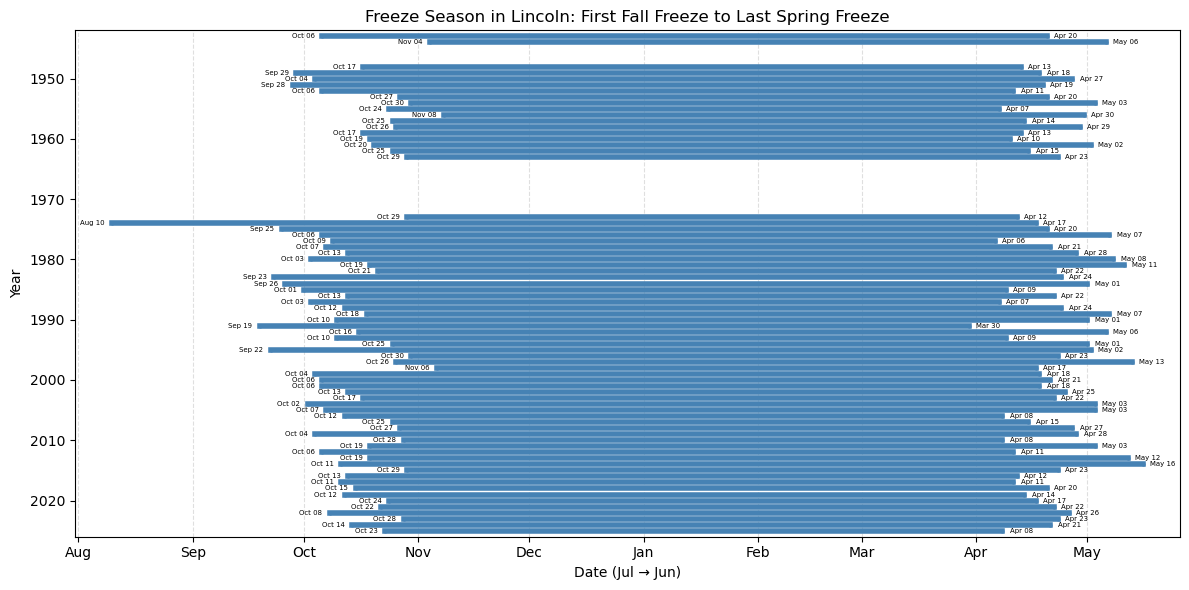

In [18]:
# Use a fixed leap year as the calendar backbone so Feb 29 never breaks
REF_YEAR = 2000

def doy_to_ref_date(year, doy):
    """Map a real DOY to a reference-year date, wrapping winter DOYs into next ref year."""
    real_date = date(int(year), 1, 1) + pd.Timedelta(days=int(doy) - 1)
    # If month >= 7, it's a fall date — put it in REF_YEAR
    # If month < 7, it's a spring date — put it in REF_YEAR + 1
    if real_date.month >= 7:
        return date(REF_YEAR, real_date.month, real_date.day)
    else:
        return date(REF_YEAR + 1, real_date.month, real_date.day)

fi = freeze_indices.dropna(subset=['last_spring_freeze_doy', 'first_fall_freeze_doy']).copy()

fi['fall_ref']   = [doy_to_ref_date(y, d) for y, d in zip(fi.index, fi['first_fall_freeze_doy'])]
fi['spring_ref'] = [doy_to_ref_date(y, d) for y, d in zip(fi.index, fi['last_spring_freeze_doy'])]

fig, ax = plt.subplots(figsize=(12, 6))  # reduced from 14

years = fi.index.tolist()

for year in years:
    row = fi.loc[year]
    ax.plot(
        [row['fall_ref'], row['spring_ref']],
        [year, year],
        color='steelblue', linewidth=4, alpha=1
    )
    ax.plot(row['fall_ref'],   year, 'o', color='steelblue', markersize=2)
    ax.plot(row['spring_ref'], year, 'o', color='steelblue', markersize=2)

    ax.text(row['fall_ref'] - pd.Timedelta(days=2), year, 
            pd.Timestamp(row['fall_ref']).strftime('%b %d'),
            ha='right', va='center', fontsize=5, color='black')
    ax.text(row['spring_ref'] + pd.Timedelta(days=2), year,
            pd.Timestamp(row['spring_ref']).strftime('%b %d'),
            ha='left', va='center', fontsize=5, color='black')

# X-axis: July 1 to June 30 spanning REF_YEAR to REF_YEAR+1
ax.set_xlim(
    fi['fall_ref'].min() - pd.Timedelta(days=10),
    fi['spring_ref'].max() + pd.Timedelta(days=10)
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Y-axis: past at top, present at bottom
ax.set_ylim(max(years) + 1, min(years) - 1)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))

ax.set_xlabel('Date (Jul → Jun)')
ax.set_ylabel('Year')
ax.set_title(f'Freeze Season in {name}: First Fall Freeze to Last Spring Freeze')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Hot days

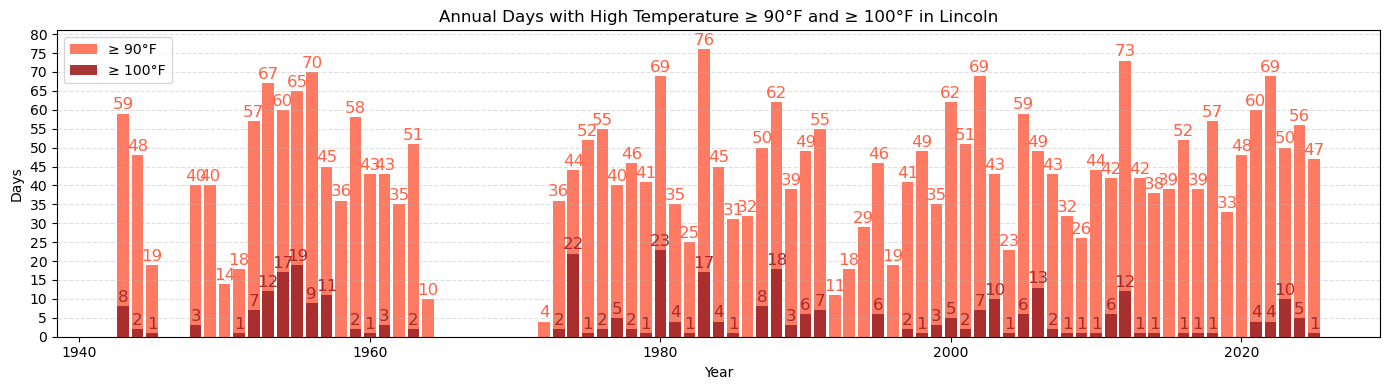

In [21]:
current_year = pd.Timestamp.now().year
hot_days_90f = daily_temps[(daily_temps['tmax'] >= 90) & (daily_temps['year'] < current_year)]
hot_days_100f = daily_temps[(daily_temps['tmax'] >= 100) & (daily_temps['year'] < current_year)]

hot_days_annual_90 = hot_days_90f.groupby('year').size()
hot_days_annual_100 = hot_days_100f.groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(hot_days_annual_90.index, hot_days_annual_90.values, color='tomato', width=0.8, alpha=0.85, label='≥ 90°F')
ax.bar(hot_days_annual_100.index, hot_days_annual_100.values, color='brown', width=0.8, alpha=0.95, label='≥ 100°F', zorder=3)

for year, val in hot_days_annual_90.items():
    ax.text(year, val + 0.3, str(val), ha='center', va='bottom', fontsize=12, color='tomato')

for year, val in hot_days_annual_100.items():
    ax.text(year, val + 0.3, str(val), ha='center', va='bottom', fontsize=12, color='brown')
    
ax.set_xlabel('Year')
ax.set_ylabel('Days')
ax.set_title(f'Annual Days with High Temperature ≥ 90°F and ≥ 100°F in {name}')
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(0, max(hot_days_annual_90.values) + 5)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Hourly precipitation

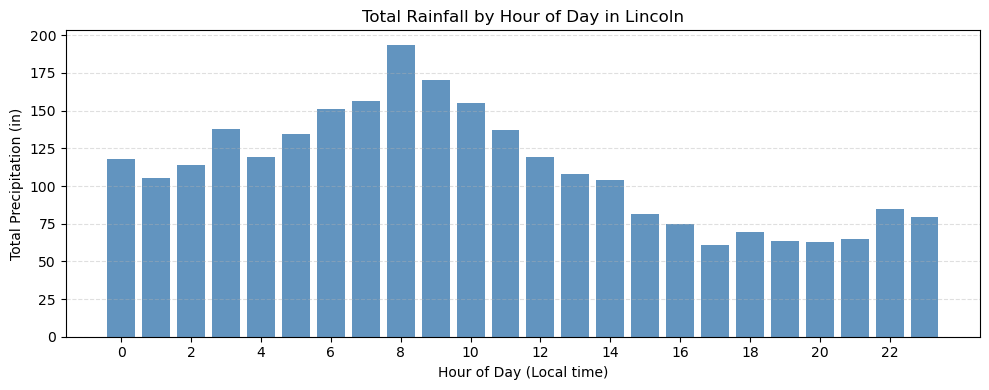

In [24]:
df['hour'] = df['datetime'].dt.hour
hourly_rain = df.groupby('hour')['precip_inches'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_rain.index, hourly_rain.values, color='steelblue', alpha=0.85)
ax.set_xlabel('Hour of Day (Local time)')
ax.set_ylabel('Total Precipitation (in)')
ax.set_title(f'Total Rainfall by Hour of Day in {name}')
ax.set_xticks(range(0, 24, 2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Annual precipiation

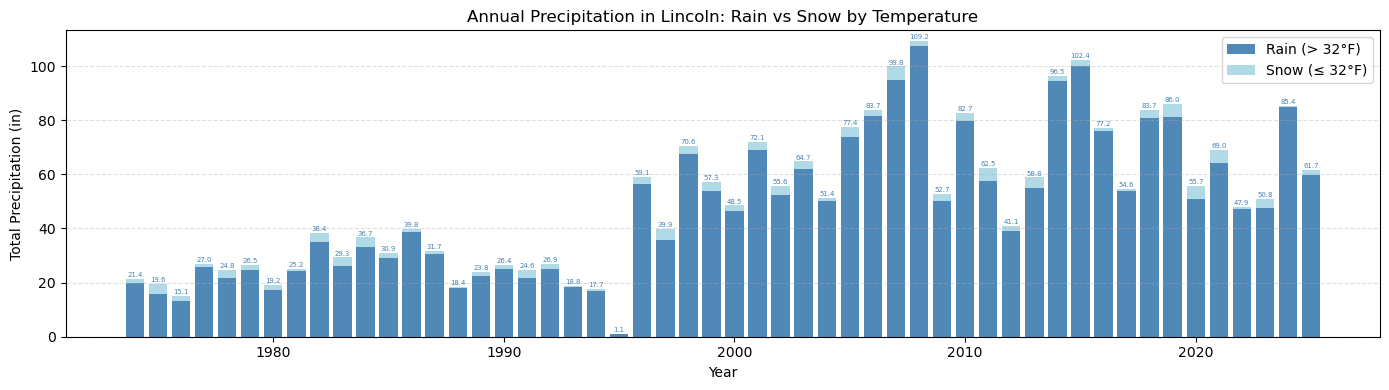

In [32]:
# Split precip by temp at time of observation
rain = df[(df['year'] < current_year) & (df['temp_f'] > 32)]
snow = df[(df['year'] < current_year) & (df['temp_f'] <= 32)]

annual_rain_only = rain.groupby('year')['precip_inches'].sum()
annual_snow      = snow.groupby('year')['precip_inches'].sum()
first_valid_year = annual_rain_only[annual_rain_only > 0].index[1]  # second year with valid values

# Align indices
annual_rain_only, annual_snow = annual_rain_only.align(annual_snow, fill_value=0)
annual_rain_only = annual_rain_only[annual_rain_only.index >= first_valid_year]
annual_snow      = annual_snow[annual_snow.index >= first_valid_year]
annual_total     = annual_rain_only + annual_snow

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(annual_rain_only.index, annual_rain_only.values,
       color='steelblue', alpha=0.95, width=0.8, label='Rain (> 32°F)')
ax.bar(annual_snow.index, annual_snow.values,
       bottom=annual_rain_only.values,
       color='lightblue', alpha=0.95, width=0.8, label='Snow (≤ 32°F)')

for year, val in annual_total.items():
    ax.text(year, val + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=5, color='steelblue')

ax.set_xlabel('Year')
ax.set_ylabel('Total Precipitation (in)')
ax.set_title(f'Annual Precipitation in {name}: Rain vs Snow by Temperature')
ax.set_ylim(0, annual_total.max() + 4)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Planning:

### Annual visibility

### Daily relative humidity

### Peak wind gusts

Summary cells, challenge user to expand beyond given info